### **Akurasi dan Stabilitas**    
pertanyaan yang sama seperti pada kasus satu dimensi, yaitu apakah skema numerik kita konvergen. Untuk menjawabnya, kita perlu meninjau $\textit{local truncation error}$ (LTE) dan stabilitas metode.

Kita tahu bahwa LTE didefinisikan sebagai
$$\begin{aligned}
    \tau_{ij} &= \frac{1}{\Delta x^2} (u(x_{i-1}, y_{j}) + u(x_{i+1}, y_{j}) + u(x_{i}, y_{j-1}) + u(x_{i}, y_{j+1}) - 4 u(x_{i}, y_{j})) - f(x_i, y_j)
\end{aligned}$$

Untuk menghitung ekspresi ini, kita memerlukan deret Taylor pada setiap arah.

**Untuk arah-$x$:**
$$\begin{aligned}
    u(x_{i+1}, y_{j}) &= u(x_{i}, y_{j}) + \Delta x u(x_{i}, y_{j})_x + \frac{\Delta x^2}{2} u(x_{i}, y_{j})_{xx} + \frac{\Delta x^3}{6} u(x_{i}, y_{j})_{xxx} + \frac{\Delta x^4}{24} u(x_{i}, y_{j})_{xxxx} + \mathcal{O}(\Delta x^5) \\
    u(x_{i-1}, y_{j}) &= u(x_{i}, y_{j}) - \Delta x u(x_{i}, y_{j})_x + \frac{\Delta x^2}{2} u(x_{i}, y_{j})_{xx} - \frac{\Delta^3}{6} u(x_{i}, y_{j})_{xxx} + \frac{\Delta x^4}{24} u(x_{i}, y_{j})_{xxxx} + \mathcal{O}(\Delta x^5)
\end{aligned}$$

**Untuk arah-$y$:**
$$\begin{aligned}
    u(x_{i}, y_{j+1}) &= u(x_{i}, y_{j}) + \Delta y u(x_{i}, y_{j})_y + \frac{\Delta y^2}{2} u(x_{i}, y_{j})_{yy} + \frac{\Delta y^3}{6} u(x_{i}, y_{j})_{yyy} + \frac{\Delta y^4}{24} u(x_{i}, y_{j})_{yyyy} + \mathcal{O}(\Delta y^5) \\
    u(x_{i}, y_{j-1}) &= u(x_{i}, y_{j}) - \Delta y u(x_{i}, y_{j})_y + \frac{\Delta y^2}{2} u(x_{i}, y_{j})_{yy} - \frac{\Delta y^3}{6} u(x_{i}, y_{j})_{yyy} + \frac{\Delta y^4}{24} u(x_{i}, y_{j})_{yyyy} + \mathcal{O}(\Delta y^5)
\end{aligned}$$

Dengan menggunakan ekspansi Taylor tersebut, penurunan LTE secara rinci adalah sebagai berikut.

Jumlahkan dua ekspansi arah-$x$:
$$\begin{aligned}
u(x_{i-1},y_j)+u(x_{i+1},y_j)
&= 2u(x_i,y_j)
+ \Delta x^2 u_{xx}(x_i,y_j)
+ \frac{\Delta x^4}{12}u_{xxxx}(x_i,y_j)
+ \mathcal O(\Delta x^6).
\end{aligned}$$

Jumlahkan dua ekspansi arah-$y$:
$$\begin{aligned}
u(x_i,y_{j-1})+u(x_i,y_{j+1})
&= 2u(x_i,y_j)
+ \Delta y^2 u_{yy}(x_i,y_j)
+ \frac{\Delta y^4}{12}u_{yyyy}(x_i,y_j)
+ \mathcal O(\Delta y^6).
\end{aligned}$$

Substitusikan ke definisi LTE:
$$\begin{aligned}
\tau_{ij}
&= \frac{1}{\Delta x^2}\Big[
\big(2u + \Delta x^2 u_{xx} + \frac{\Delta x^4}{12}u_{xxxx} + \cdots\big)
+\big(2u + \Delta y^2 u_{yy} + \frac{\Delta y^4}{12}u_{yyyy} + \cdots\big)
-4u
\Big]-f(x_i,y_j).
\end{aligned}$$

Untuk kasus kisi seragam yang digunakan di sini ($\Delta y=\Delta x$), didapat:
$$\begin{aligned}
\tau_{ij}
&= (u_{xx}+u_{yy})-f
+\frac{\Delta x^2}{12}(u_{xxxx}+u_{yyyy})+\mathcal O(\Delta x^4).
\end{aligned}$$

Karena PDE kontinu memenuhi $u_{xx}+u_{yy}=f$, maka suku utama saling meniadakan dan tersisa
$$
    \tau_{ij} =  \frac{1}{12} \Delta x^2 (u_{xxxx} + u_{yyyy}) + \mathcal{O}(\Delta x^4).
$$

Bentuk sistem linear untuk galat menjadi
$$
    A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}
$$
dengan sekarang $A$ adalah diskretisasi yang telah kita tulis sebelumnya. Perhatikan bahwa pengurutan persamaan tidak berpengaruh saat menganalisis galat.

Untuk stabilitas dalam norma-2, kita kembali dapat mempertimbangkan nilai eigen dari sistem di atas. Nilai eigennya adalah
$$
    \lambda_{pq} = \frac{2}{\Delta x^2} ((\cos(p \pi \Delta x) - 1) + (\cos(q \pi \Delta x) - 1))
$$
dengan vektor eigen terkait
$$
    v^{p,q}_{ij} = \sin(p \pi i \Delta x) \sin(q \pi j \Delta x).
$$

Karena nilai eigen selalu negatif ketat ($A$ memang negatif definit), maka nilai yang paling dekat ke titik asal adalah
$$
    \lambda_{11} = -2 \pi^2 + \mathcal{O}(\Delta x^2)
$$
yang menghasilkan jari-jari spektral
$$
    \rho((A^{\Delta x})^{-1}) = \frac{1}{\lambda_{11}} \approx -\frac{1}{2 \pi^2}.
$$

Kita dapat memakai batas pada $A^{-1}$ ini untuk menunjukkan stabilitas dan dengan demikian konvergensi diskretisasi.

Besaran lain yang serupa dan berguna untuk dipertimbangkan adalah $\textit{condition number}$ dari matriks $A$. Ingat bahwa ini dapat didefinisikan sebagai
$$
    \kappa(A) = ||A|| ||A^{-1}||.
$$

Dalam norma-2, kita sudah mengetahui informasi tentang $A^{-1}$, tetapi kita juga dapat memakai ekspresi di atas untuk mencari jari-jari spektral dari $A$. Nilai eigen terbesarnya adalah
$$
    \lambda_{mm} \approx -\frac{8}{\Delta x^2}
$$
sehingga didapat condition number
$$
    \kappa_2(A) = \frac{4}{\pi^2 \Delta x^2} = \mathcal{O}\left(\frac{1}{\Delta x^2}\right)
$$
Matriks ini karenanya menjadi semakin $\textit{ill-conditioned}$ saat $\Delta x \rightarrow 0$.

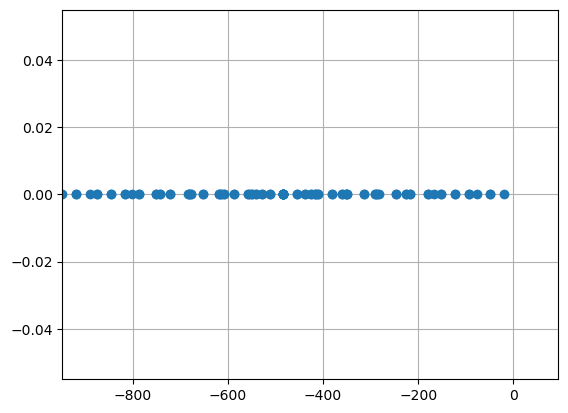

In [5]:
# Hitung nilai eigen
m = 10
delta_x = 1.0 / float(m + 1)
eig_vals = numpy.empty(m**2)
for (i, p) in enumerate(numpy.arange(1, m + 1)):
    for (j, q) in enumerate(numpy.arange(1, m + 1)):
        eig_vals[i * m + j] = 2.0 / delta_x**2 * ((numpy.cos(p * numpy.pi * delta_x) - 1.0) +
                                                  (numpy.cos(q * numpy.pi * delta_x) - 1.0))

# Plot nilai eigen dari Laplasian 5-titik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(eig_vals.real, eig_vals.imag, 'o')
axes.grid(True)
axes.set_xlim(numpy.amin(eig_vals), -numpy.amin(eig_vals) * 0.1)
plt.show()


### **Laplacian 9-Titik**

Pendekatan lain untuk mendiskretisasi Laplacian $\nabla^2$ disebut stencil 9-titik. Stencil ini didefinisikan sebagai
$$
    \nabla^2 u_{ij} = \frac{1}{6 \Delta x^2} \left(4 u_{i-1,j} + 4 u_{i+1,j} + 4 u_{i,j-1} + 4 u_{i,j+1} + u_{i-1,j-1} + u_{i+1,j-1} + u_{i+1,j+1} + u_{i-1,j+1} -20 u_{i,j}  \right).
$$

Kita juga dapat mencari LTE seperti sebelumnya dan memperoleh
$$
    \tau_{ij} = \frac{\Delta x^2}{12} (u_{xxxx} + 2u_{xxyy} + u_{yyyy}) + \mathcal{O}(\Delta x^4).
$$

Lalu apa yang kita peroleh? Jika kita melihat \(\tau_{ij}\), suku turunan tersebut sebenarnya dapat ditulis sebagai
$$
    u_{xxxx} + 2u_{xxyy} + u_{yyyy} = \nabla^2 (\nabla^2 u) \equiv \nabla^4 u,
$$
yaitu Laplacian dari Laplacian (disebut \textit{biharmonic operator}). Jika kembali ke PDE asal, kita dapat langsung melihat bentuk galat ini dengan mencatat
$$\begin{aligned}
    \nabla^2 u &= f \\
    \nabla^2 (\nabla^2 u) &= \nabla^2 f
\end{aligned}$$

Dengan demikian, suku galat dapat dihitung langsung dengan mengambil Laplacian pada ruas kanan PDE asal.

Hal ini juga dapat menghasilkan metode orde lebih tinggi. Jika kita definisikan
$$
    f_{ij} = f(x_i, y_j) + \frac{\Delta x^2}{12} \nabla^2 f(x_i, y_j)
$$
kita bisa meniadakan suku berikutnya pada LTE. Ini tetap dapat dilakukan bahkan jika kita hanya memiliki fungsi $f(x,y)$ pada himpunan titik diskret, karena kita bisa menggunakan stencil 5-titik.
